In [1]:
import os
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

warnings.filterwarnings("ignore")

print("Imports completed.")

Imports completed.


In [2]:
PROJECT_ROOT = Path(r"C:\Users\ADMIN\FinGraph-Sentinel")

PHASE14_DIR = PROJECT_ROOT / "data" / "results" / "phase14"
PHASE14_DIR.mkdir(parents=True, exist_ok=True)

SYSTEMIC_RISK_PATH = (
    PROJECT_ROOT / "data" / "results" / "dynamic_systemic_risk.csv"
)

TEMPORAL_DATASET_PATH = (
    PROJECT_ROOT / "data" / "results" / "phase13"
    / "phase13_expanded_temporal_dataset.csv"
)

RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("Project root:", PROJECT_ROOT)
print("Phase 14 output directory:", PHASE14_DIR)
print("Systemic risk file exists:", SYSTEMIC_RISK_PATH.exists())
print("Temporal dataset exists:", TEMPORAL_DATASET_PATH.exists())

Project root: C:\Users\ADMIN\FinGraph-Sentinel
Phase 14 output directory: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase14
Systemic risk file exists: True
Temporal dataset exists: True


In [3]:
systemic_risk_df = pd.read_csv(SYSTEMIC_RISK_PATH)

systemic_risk_df["date"] = pd.to_datetime(
    systemic_risk_df["date"],
    errors="coerce"
).dt.normalize()

systemic_risk_df = (
    systemic_risk_df
    .dropna(subset=["date"])
    .sort_values("date")
    .drop_duplicates(subset=["date"])
    .reset_index(drop=True)
)

print("Shape:", systemic_risk_df.shape)
print("Date range:")
print(systemic_risk_df["date"].min(), "to", systemic_risk_df["date"].max())

display(systemic_risk_df.head())

Shape: (120, 6)
Date range:
2021-11-12 00:00:00 to 2026-08-13 00:00:00


,date,company,degree,betweenness,pagerank,systemic_risk_score
0,2021-11-12,AAPL,0.333333,0.000000,0.137777,0.155111
1,2021-11-29,V,0.111111,0.000000,0.134228,0.087025
2,2021-12-13,V,0.111111,0.000000,0.134228,0.087025
3,2021-12-28,MSFT,0.333333,0.027778,0.136366,0.162880
4,2022-01-11,AAPL,0.333333,0.000000,0.120550,0.148220


In [4]:
temporal_df = pd.read_csv(TEMPORAL_DATASET_PATH)

temporal_df["date"] = pd.to_datetime(
    temporal_df["date"],
    errors="coerce"
).dt.normalize()

target_labels_df = (
    temporal_df[["date", "future_stress_event"]]
    .dropna(subset=["date"])
    .copy()
)

target_labels_df["future_stress_event"] = pd.to_numeric(
    target_labels_df["future_stress_event"],
    errors="coerce"
)

target_labels_df = (
    target_labels_df
    .dropna(subset=["future_stress_event"])
    .drop_duplicates(subset=["date"])
    .sort_values("date")
    .reset_index(drop=True)
)

target_labels_df["future_stress_event"] = (
    target_labels_df["future_stress_event"].astype(int)
)

print("Target shape:", target_labels_df.shape)
print(target_labels_df["future_stress_event"].value_counts())

Target shape: (1175, 2)
future_stress_event
0    1027
1     148
Name: count, dtype: int64


In [5]:
excluded_columns = {
    "date",
    "ticker",
    "company",
    "future_stress_event",
    "target",
    "future_max_stress"
}

candidate_signals = [
    column
    for column in systemic_risk_df.columns
    if column not in excluded_columns
    and pd.api.types.is_numeric_dtype(systemic_risk_df[column])
]

signal_df = systemic_risk_df[["date"] + candidate_signals].copy()

signal_df = signal_df.replace([np.inf, -np.inf], np.nan)

valid_signals = []

for column in candidate_signals:
    non_missing = signal_df[column].notna().sum()
    unique_values = signal_df[column].nunique(dropna=True)

    if non_missing > 0 and unique_values > 1:
        valid_signals.append(column)

signal_df = signal_df[["date"] + valid_signals].copy()

print("Candidate signals:", len(candidate_signals))
print("Valid signals:", len(valid_signals))
print(valid_signals)

Candidate signals: 4
Valid signals: 4
['degree', 'betweenness', 'pagerank', 'systemic_risk_score']


In [6]:
for column in valid_signals:
    signal_df[column] = (
        signal_df[column]
        .interpolate(method="linear", limit_direction="both")
        .fillna(signal_df[column].median())
        .fillna(0)
    )

missing_count = signal_df[valid_signals].isna().sum().sum()

print("Remaining missing values:", missing_count)
display(signal_df.describe().T)

Remaining missing values: 0


,count,mean,min,25%,50%,75%,max,std
date,120,2024-03-28 18:48:00,2021-11-12 00:00:00,2023-01-21 06:00:00,2024-03-28 12:00:00,2025-06-06 12:00:00,2026-08-13 00:00:00,NaN
degree,120.0,0.369444,0.0,0.111111,0.222222,0.583333,1.0,0.338173
betweenness,120.0,0.02338,0.0,0.0,0.0,0.0,0.305556,0.06058
pagerank,120.0,0.116816,0.018072,0.09236,0.112174,0.13983,0.312496,0.049132
systemic_risk_score,120.0,0.164574,0.007229,0.087025,0.116378,0.267008,0.419601,0.109555


In [7]:
normalized_signal_df = signal_df[["date"]].copy()

for column in valid_signals:
    normalized_signal_df[column] = (
        signal_df[column]
        .rank(method="average", pct=True) * 100
    )

print("Normalized signal data:")
display(normalized_signal_df.head())

Normalized signal data:


,date,degree,betweenness,pagerank,systemic_risk_score
0,2021-11-12,63.333333,40.833333,74.166667,61.666667
1,2021-11-29,25.000000,40.833333,69.166667,23.333333
2,2021-12-13,25.000000,40.833333,70.000000,24.166667
3,2021-12-28,63.333333,83.750000,73.333333,64.166667
4,2022-01-11,63.333333,40.833333,58.333333,60.000000


In [8]:
normalized_values = normalized_signal_df[valid_signals]

normalized_signal_df["multi_signal_risk_score"] = (
    normalized_values.mean(axis=1)
)

normalized_signal_df["risk_percentile"] = (
    normalized_signal_df["multi_signal_risk_score"]
    .rank(method="average", pct=True) * 100
)

risk_score_df = normalized_signal_df[
    ["date", "multi_signal_risk_score", "risk_percentile"]
].copy()

display(risk_score_df.head())

print(risk_score_df["multi_signal_risk_score"].describe())

,date,multi_signal_risk_score,risk_percentile
0,2021-11-12,60.000000,69.166667
1,2021-11-29,39.583333,27.500000
2,2021-12-13,40.000000,28.333333
3,2021-12-28,71.145833,85.000000
4,2022-01-11,55.625000,60.833333


count    120.000000
mean      50.416667
std       19.756479
min       11.770833
25%       38.932292
50%       50.312500
75%       64.895833
max       92.083333
Name: multi_signal_risk_score, dtype: float64


In [9]:
validation_df = pd.merge(
    risk_score_df,
    target_labels_df,
    on="date",
    how="inner"
).sort_values("date").reset_index(drop=True)

print("Validation shape:", validation_df.shape)
print(
    "Date range:",
    validation_df["date"].min(),
    "to",
    validation_df["date"].max()
)

print("\nTarget distribution:")
print(validation_df["future_stress_event"].value_counts())

display(validation_df.head())

Validation shape: (118, 4)
Date range: 2021-11-12 00:00:00 to 2026-07-16 00:00:00

Target distribution:
future_stress_event
0    102
1     16
Name: count, dtype: int64


,date,multi_signal_risk_score,risk_percentile,future_stress_event
0,2021-11-12,60.000000,69.166667,0
1,2021-11-29,39.583333,27.500000,0
2,2021-12-13,40.000000,28.333333,0
3,2021-12-28,71.145833,85.000000,1
4,2022-01-11,55.625000,60.833333,0


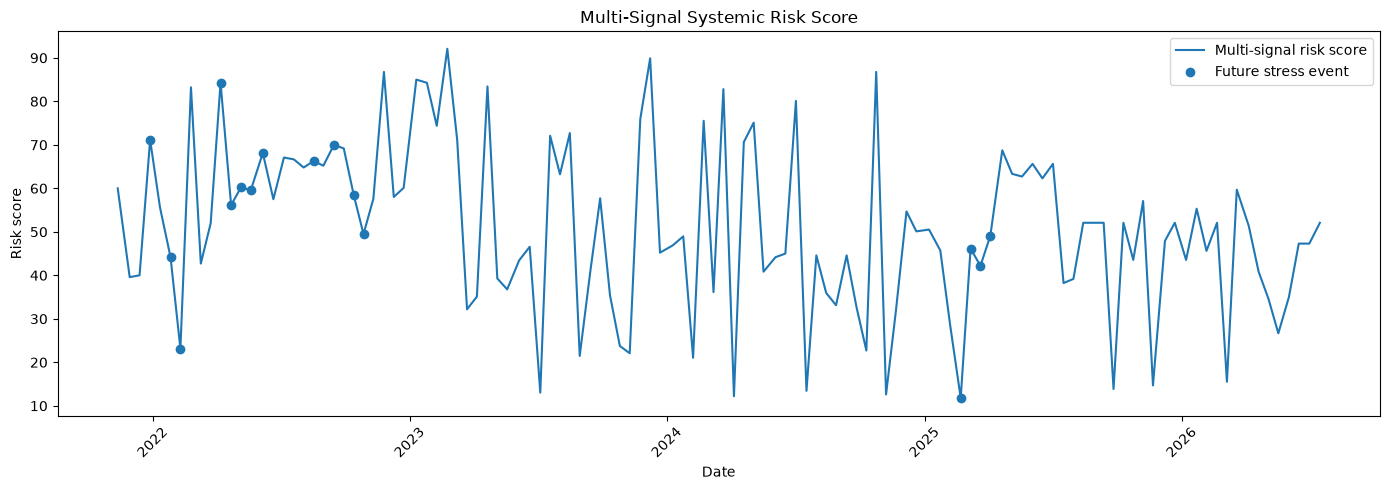

In [10]:
plt.figure(figsize=(14, 5))

plt.plot(
    validation_df["date"],
    validation_df["multi_signal_risk_score"],
    label="Multi-signal risk score"
)

stress_dates = validation_df.loc[
    validation_df["future_stress_event"] == 1,
    "date"
]

stress_scores = validation_df.loc[
    validation_df["future_stress_event"] == 1,
    "multi_signal_risk_score"
]

plt.scatter(
    stress_dates,
    stress_scores,
    label="Future stress event"
)

plt.title("Multi-Signal Systemic Risk Score")
plt.xlabel("Date")
plt.ylabel("Risk score")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
y_true = validation_df["future_stress_event"].astype(int)
risk_scores = validation_df["multi_signal_risk_score"]

if y_true.nunique() == 2:
    overall_roc_auc = roc_auc_score(y_true, risk_scores)
    overall_pr_auc = average_precision_score(y_true, risk_scores)

    print(f"Overall ROC-AUC: {overall_roc_auc:.4f}")
    print(f"Overall PR-AUC: {overall_pr_auc:.4f}")
else:
    print("ROC-AUC and PR-AUC cannot be calculated.")
    print("Only one target class is present.")

Overall ROC-AUC: 0.5677
Overall PR-AUC: 0.1619


In [12]:
n_rows = len(validation_df)

train_end = int(n_rows * 0.60)
validation_end = int(n_rows * 0.80)

train_df = validation_df.iloc[:train_end].copy()
val_df = validation_df.iloc[train_end:validation_end].copy()
test_df = validation_df.iloc[validation_end:].copy()

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

print("\nDate boundaries:")
print("Train:", train_df["date"].min(), "to", train_df["date"].max())
print("Validation:", val_df["date"].min(), "to", val_df["date"].max())
print("Test:", test_df["date"].min(), "to", test_df["date"].max())

print("\nClass distributions:")
print("Train:\n", train_df["future_stress_event"].value_counts())
print("Validation:\n", val_df["future_stress_event"].value_counts())
print("Test:\n", test_df["future_stress_event"].value_counts())

Train: (70, 4)
Validation: (24, 4)
Test: (24, 4)

Date boundaries:
Train: 2021-11-12 00:00:00 to 2024-08-14 00:00:00
Validation: 2024-08-28 00:00:00 to 2025-07-31 00:00:00
Test: 2025-08-14 00:00:00 to 2026-07-16 00:00:00

Class distributions:
Train:
 future_stress_event
0    58
1    12
Name: count, dtype: int64
Validation:
 future_stress_event
0    20
1     4
Name: count, dtype: int64
Test:
 future_stress_event
0    24
Name: count, dtype: int64


In [13]:
threshold_percentiles = [75, 80, 85, 90, 95]

train_thresholds = {
    percentile: np.percentile(
        train_df["multi_signal_risk_score"],
        percentile
    )
    for percentile in threshold_percentiles
}

print("Training-fitted thresholds:")

for percentile, threshold in train_thresholds.items():
    print(f"{percentile}th percentile: {threshold:.4f}")

Training-fitted thresholds:
75th percentile: 71.0156
80th percentile: 73.0417
85th percentile: 75.7917
90th percentile: 83.2500
95th percentile: 84.6719


In [14]:
def evaluate_threshold(dataframe, threshold):
    y_true = dataframe["future_stress_event"].astype(int)

    y_pred = (
        dataframe["multi_signal_risk_score"] >= threshold
    ).astype(int)

    return {
        "samples": len(dataframe),
        "actual_events": int(y_true.sum()),
        "predicted_alerts": int(y_pred.sum()),
        "precision": precision_score(
            y_true, y_pred, zero_division=0
        ),
        "recall": recall_score(
            y_true, y_pred, zero_division=0
        ),
        "f1": f1_score(
            y_true, y_pred, zero_division=0
        ),
        "true_positives": int(
            ((y_true == 1) & (y_pred == 1)).sum()
        ),
        "false_positives": int(
            ((y_true == 0) & (y_pred == 1)).sum()
        ),
        "false_negatives": int(
            ((y_true == 1) & (y_pred == 0)).sum()
        )
    }

In [15]:
robustness_results = []

split_data = {
    "train": train_df,
    "validation": val_df,
    "test": test_df
}

for percentile, threshold in train_thresholds.items():
    for split_name, split_dataframe in split_data.items():

        metrics = evaluate_threshold(
            split_dataframe,
            threshold
        )

        metrics["split"] = split_name
        metrics["threshold_percentile"] = percentile
        metrics["threshold_value"] = threshold

        robustness_results.append(metrics)

robustness_df = pd.DataFrame(robustness_results)

robustness_df = robustness_df[
    [
        "split",
        "threshold_percentile",
        "threshold_value",
        "samples",
        "actual_events",
        "predicted_alerts",
        "precision",
        "recall",
        "f1",
        "true_positives",
        "false_positives",
        "false_negatives"
    ]
]

display(robustness_df)

,split,threshold_percentile,threshold_value,samples,actual_events,predicted_alerts,precision,recall,f1,true_positives,false_positives,false_negatives
0,train,75,71.015625,70,12,18,0.111111,0.166667,0.133333,2,16,10
1,validation,75,71.015625,24,4,1,0.000000,0.000000,0.000000,0,1,4
2,test,75,71.015625,24,0,0,0.000000,0.000000,0.000000,0,0,0
3,train,80,73.041667,70,12,14,0.071429,0.083333,0.076923,1,13,11
4,validation,80,73.041667,24,4,1,0.000000,0.000000,0.000000,0,1,4
5,test,80,73.041667,24,0,0,0.000000,0.000000,0.000000,0,0,0
6,train,85,75.791667,70,12,11,0.090909,0.083333,0.086957,1,10,11
7,validation,85,75.791667,24,4,1,0.000000,0.000000,0.000000,0,1,4
8,test,85,75.791667,24,0,0,0.000000,0.000000,0.000000,0,0,0
9,train,90,83.250000,70,12,7,0.142857,0.083333,0.105263,1,6,11


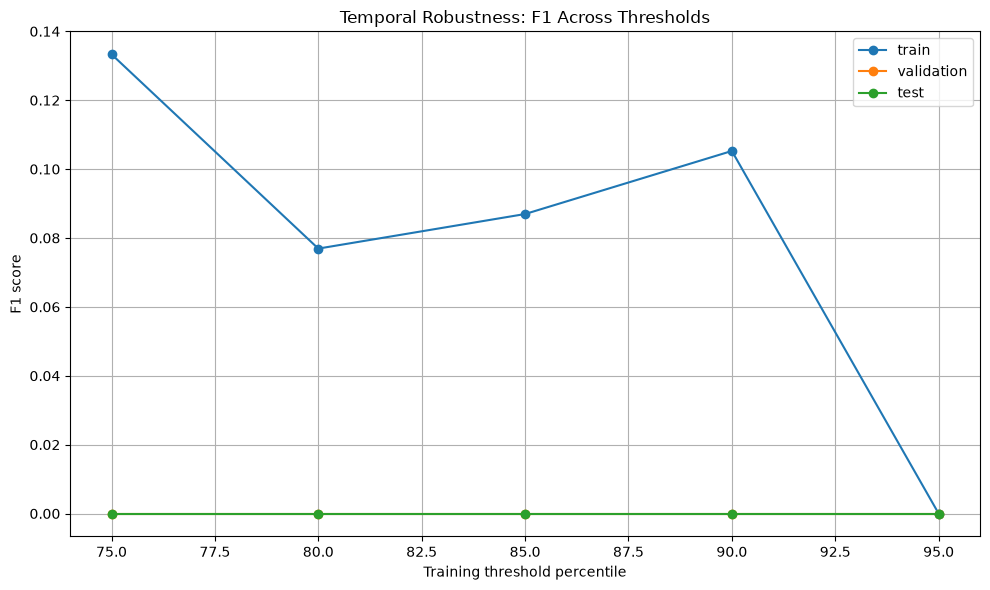

In [16]:
plt.figure(figsize=(10, 6))

for split_name in ["train", "validation", "test"]:
    subset = robustness_df[
        robustness_df["split"] == split_name
    ]

    plt.plot(
        subset["threshold_percentile"],
        subset["f1"],
        marker="o",
        label=split_name
    )

plt.title("Temporal Robustness: F1 Across Thresholds")
plt.xlabel("Training threshold percentile")
plt.ylabel("F1 score")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [17]:
risk_score_path = (
    PHASE14_DIR / "multi_signal_systemic_risk_score.csv"
)

robustness_path = (
    PHASE14_DIR / "temporal_robustness_results.csv"
)

config_path = (
    PHASE14_DIR / "multi_signal_configuration.json"
)

risk_score_df.to_csv(risk_score_path, index=False)
robustness_df.to_csv(robustness_path, index=False)

configuration = {
    "phase": "Phase 14",
    "method": "Multi-signal systemic risk score",
    "normalization": "Full-dataset percentile ranking",
    "aggregation": "Mean of normalized signals",
    "signals": valid_signals,
    "threshold_percentiles": threshold_percentiles,
    "split_ratio": {
        "train": 0.60,
        "validation": 0.20,
        "test": 0.20
    },
    "random_seed": RANDOM_SEED,
    "research_limitation": (
        "The exploratory score uses full-dataset normalization. "
        "Threshold robustness evaluation is fitted on training scores."
    )
}

with open(config_path, "w", encoding="utf-8") as file:
    json.dump(configuration, file, indent=4)

print("Saved:")
print(risk_score_path)
print(robustness_path)
print(config_path)

Saved:
C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase14\multi_signal_systemic_risk_score.csv
C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase14\temporal_robustness_results.csv
C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase14\multi_signal_configuration.json


In [18]:
print("=" * 60)
print("PHASE 14 SUMMARY")
print("=" * 60)

print("Valid signals:", len(valid_signals))
print("Validation samples:", len(validation_df))
print("Train samples:", len(train_df))
print("Validation samples:", len(val_df))
print("Test samples:", len(test_df))

if y_true.nunique() == 2:
    print(f"Overall ROC-AUC: {overall_roc_auc:.4f}")
    print(f"Overall PR-AUC: {overall_pr_auc:.4f}")

print("\nOutput files:")
for path in PHASE14_DIR.glob("*"):
    print("-", path.name)

PHASE 14 SUMMARY
Valid signals: 4
Validation samples: 118
Train samples: 70
Validation samples: 24
Test samples: 24
Overall ROC-AUC: 0.5677
Overall PR-AUC: 0.1619

Output files:
- multi_signal_alert_threshold_results.csv
- multi_signal_configuration.json
- multi_signal_risk_validation.csv
- multi_signal_systemic_risk_score.csv
- phase14_experiment_registry.json
- temporal_robustness_results.csv


In [19]:
print("Signals used in the score:")

for signal in valid_signals:
    print("-", signal)

display(signal_df[["date"] + valid_signals].describe().T)

Signals used in the score:
- degree
- betweenness
- pagerank
- systemic_risk_score


,count,mean,min,25%,50%,75%,max,std
date,120,2024-03-28 18:48:00,2021-11-12 00:00:00,2023-01-21 06:00:00,2024-03-28 12:00:00,2025-06-06 12:00:00,2026-08-13 00:00:00,NaN
degree,120.0,0.369444,0.0,0.111111,0.222222,0.583333,1.0,0.338173
betweenness,120.0,0.02338,0.0,0.0,0.0,0.0,0.305556,0.06058
pagerank,120.0,0.116816,0.018072,0.09236,0.112174,0.13983,0.312496,0.049132
systemic_risk_score,120.0,0.164574,0.007229,0.087025,0.116378,0.267008,0.419601,0.109555


In [20]:
signal_validation_df = pd.merge(
    signal_df,
    target_labels_df,
    on="date",
    how="inner"
).sort_values("date")

signal_correlations = []

for signal in valid_signals:
    correlation = signal_validation_df[
        [signal, "future_stress_event"]
    ].corr().iloc[0, 1]

    signal_correlations.append({
        "signal": signal,
        "correlation_with_target": correlation
    })

signal_correlation_df = pd.DataFrame(signal_correlations)

display(
    signal_correlation_df.sort_values(
        "correlation_with_target",
        ascending=False
    )
)

,signal,correlation_with_target
0,degree,0.252834
3,systemic_risk_score,0.182464
1,betweenness,-0.109717
2,pagerank,-0.195484


In [21]:
comparison_rows = []

for signal in valid_signals:
    normal_values = signal_validation_df.loc[
        signal_validation_df["future_stress_event"] == 0,
        signal
    ]

    stress_values = signal_validation_df.loc[
        signal_validation_df["future_stress_event"] == 1,
        signal
    ]

    comparison_rows.append({
        "signal": signal,
        "normal_mean": normal_values.mean(),
        "stress_mean": stress_values.mean(),
        "normal_median": normal_values.median(),
        "stress_median": stress_values.median(),
        "normal_count": len(normal_values),
        "stress_count": len(stress_values)
    })

signal_comparison_df = pd.DataFrame(comparison_rows)

display(signal_comparison_df)

,signal,normal_mean,stress_mean,normal_median,stress_median,normal_count,stress_count
0,degree,0.342048,0.590278,0.222222,0.611111,102,16
1,betweenness,0.026416,0.006944,0.000000,0.000000,102,16
2,pagerank,0.121995,0.094574,0.120482,0.096896,102,16
3,systemic_risk_score,0.159337,0.216996,0.114966,0.218146,102,16


In [22]:
validation_df["year"] = validation_df["date"].dt.year

yearly_events = (
    validation_df
    .groupby("year")["future_stress_event"]
    .agg(
        total_observations="count",
        stress_events="sum"
    )
    .reset_index()
)

yearly_events["event_rate"] = (
    yearly_events["stress_events"]
    / yearly_events["total_observations"]
)

display(yearly_events)

,year,total_observations,stress_events,event_rate
0,2021,4,1,0.25
1,2022,25,11,0.44
2,2023,25,0,0.00
3,2024,25,0,0.00
4,2025,25,4,0.16
5,2026,14,0,0.00


In [23]:
print("Test-period target distribution:")
print(test_df["future_stress_event"].value_counts())

print("\nTest-period dates:")
print(test_df["date"].min(), "to", test_df["date"].max())

if test_df["future_stress_event"].sum() == 0:
    print(
        "\nWARNING: Test period contains no positive stress events."
    )
    print(
        "Test F1 and recall cannot evaluate positive-event detection."
    )

Test-period target distribution:
future_stress_event
0    24
Name: count, dtype: int64

Test-period dates:
2025-08-14 00:00:00 to 2026-07-16 00:00:00

Test F1 and recall cannot evaluate positive-event detection.


In [24]:
signal_correlation_path = (
    PHASE14_DIR / "signal_target_correlations.csv"
)

signal_comparison_path = (
    PHASE14_DIR / "signal_stress_comparison.csv"
)

yearly_events_path = (
    PHASE14_DIR / "yearly_stress_event_distribution.csv"
)

signal_correlation_df.to_csv(
    signal_correlation_path,
    index=False
)

signal_comparison_df.to_csv(
    signal_comparison_path,
    index=False
)

yearly_events.to_csv(
    yearly_events_path,
    index=False
)

print("Saved diagnostic files:")
print(signal_correlation_path)
print(signal_comparison_path)
print(yearly_events_path)

Saved diagnostic files:
C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase14\signal_target_correlations.csv
C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase14\signal_stress_comparison.csv
C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase14\yearly_stress_event_distribution.csv


In [25]:
from sklearn.metrics import roc_auc_score, average_precision_score

lag_results = []

lag_periods = [0, 1, 2, 3, 5, 10]

for lag in lag_periods:
    lagged_df = validation_df.copy()

    lagged_df["lagged_target"] = (
        lagged_df["future_stress_event"]
        .shift(-lag)
    )

    lagged_df = lagged_df.dropna(
        subset=["lagged_target"]
    )

    y_lagged = lagged_df["lagged_target"].astype(int)
    scores = lagged_df["multi_signal_risk_score"]

    if y_lagged.nunique() < 2:
        lag_results.append({
            "lag": lag,
            "samples": len(lagged_df),
            "events": int(y_lagged.sum()),
            "roc_auc": np.nan,
            "pr_auc": np.nan
        })
        continue

    lag_results.append({
        "lag": lag,
        "samples": len(lagged_df),
        "events": int(y_lagged.sum()),
        "roc_auc": roc_auc_score(y_lagged, scores),
        "pr_auc": average_precision_score(y_lagged, scores)
    })

lag_results_df = pd.DataFrame(lag_results)

display(lag_results_df)

,lag,samples,events,roc_auc,pr_auc
0,0,118,16,0.567708,0.161930
1,1,117,16,0.532488,0.148498
2,2,116,16,0.566563,0.166396
3,3,115,16,0.588068,0.181249
4,5,113,15,0.545578,0.145392
5,10,108,13,0.481377,0.133360


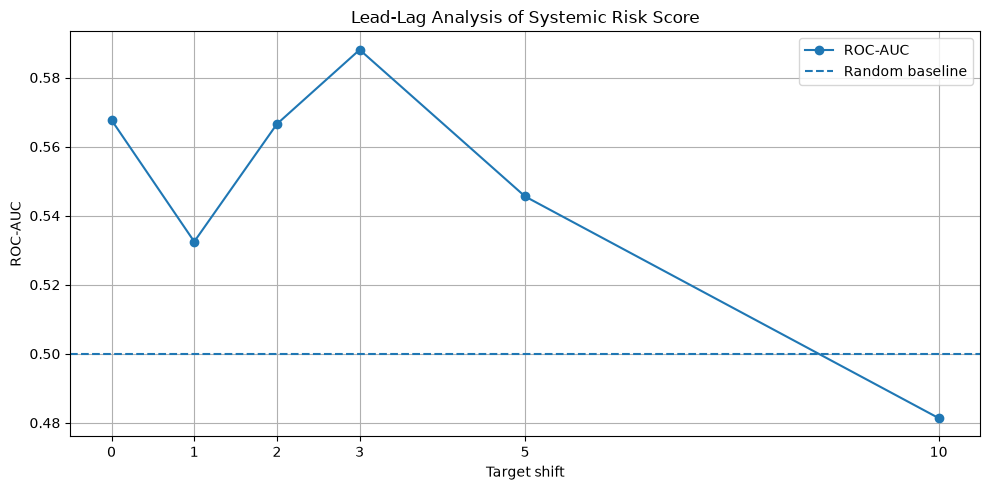

In [26]:
plt.figure(figsize=(10, 5))

plt.plot(
    lag_results_df["lag"],
    lag_results_df["roc_auc"],
    marker="o",
    label="ROC-AUC"
)

plt.axhline(
    0.5,
    linestyle="--",
    label="Random baseline"
)

plt.title("Lead-Lag Analysis of Systemic Risk Score")
plt.xlabel("Target shift")
plt.ylabel("ROC-AUC")
plt.xticks(lag_periods)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [27]:
annual_score_summary = (
    validation_df
    .assign(year=validation_df["date"].dt.year)
    .groupby("year")
    .agg(
        observations=("multi_signal_risk_score", "count"),
        mean_score=("multi_signal_risk_score", "mean"),
        median_score=("multi_signal_risk_score", "median"),
        maximum_score=("multi_signal_risk_score", "max"),
        stress_events=("future_stress_event", "sum")
    )
    .reset_index()
)

display(annual_score_summary)

,year,observations,mean_score,median_score,maximum_score,stress_events
0,2021,4,52.682292,50.000000,71.145833,1
1,2022,25,61.054167,60.104167,86.770833,11
2,2023,25,54.279167,46.562500,92.083333,0
3,2024,25,45.700000,44.583333,86.770833,0
4,2025,25,47.087500,50.520833,68.750000,4
5,2026,14,43.348214,46.458333,59.687500,0


In [28]:
top_risk_observations = (
    validation_df
    .sort_values(
        "multi_signal_risk_score",
        ascending=False
    )
    .head(20)
    .copy()
)

display(
    top_risk_observations[
        [
            "date",
            "multi_signal_risk_score",
            "risk_percentile",
            "future_stress_event"
        ]
    ]
)

,date,multi_signal_risk_score,risk_percentile,future_stress_event
32,2023-02-23,92.083333,100.000000,0
52,2023-12-08,89.895833,99.166667,0
26,2022-11-25,86.770833,97.916667,0
74,2024-10-24,86.770833,97.916667,0
29,2023-01-10,85.000000,96.666667,0
10,2022-04-07,84.270833,95.416667,1
30,2023-01-25,84.270833,95.416667,0
36,2023-04-21,83.437500,94.166667,0
7,2022-02-24,83.229167,93.333333,0
59,2024-03-21,82.812500,92.500000,0


In [29]:
capture_results = []

total_events = validation_df["future_stress_event"].sum()

for top_percent in [5, 10, 20, 30]:
    number_of_rows = max(
        1,
        int(len(validation_df) * top_percent / 100)
    )

    top_rows = validation_df.nlargest(
        number_of_rows,
        "multi_signal_risk_score"
    )

    captured_events = top_rows["future_stress_event"].sum()

    capture_rate = (
        captured_events / total_events
        if total_events > 0
        else np.nan
    )

    capture_results.append({
        "top_percent": top_percent,
        "selected_observations": number_of_rows,
        "captured_events": int(captured_events),
        "total_events": int(total_events),
        "event_capture_rate": capture_rate
    })

capture_df = pd.DataFrame(capture_results)

display(capture_df)

,top_percent,selected_observations,captured_events,total_events,event_capture_rate
0,5,5,0,16,0.0000
1,10,11,1,16,0.0625
2,20,23,3,16,0.1875
3,30,35,5,16,0.3125


In [30]:
lag_results_path = (
    PHASE14_DIR / "lead_lag_analysis.csv"
)

annual_summary_path = (
    PHASE14_DIR / "annual_risk_score_summary.csv"
)

capture_results_path = (
    PHASE14_DIR / "top_risk_event_capture.csv"
)

lag_results_df.to_csv(
    lag_results_path,
    index=False
)

annual_score_summary.to_csv(
    annual_summary_path,
    index=False
)

capture_df.to_csv(
    capture_results_path,
    index=False
)

print("Saved:")
print(lag_results_path)
print(annual_summary_path)
print(capture_results_path)

Saved:
C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase14\lead_lag_analysis.csv
C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase14\annual_risk_score_summary.csv
C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase14\top_risk_event_capture.csv


In [31]:
observed_capture = {}

for top_percent in [5, 10, 20, 30]:
    number_of_rows = max(
        1,
        int(len(validation_df) * top_percent / 100)
    )

    top_rows = validation_df.nlargest(
        number_of_rows,
        "multi_signal_risk_score"
    )

    observed_capture[top_percent] = int(
        top_rows["future_stress_event"].sum()
    )

print("Observed event capture:")
print(observed_capture)

Observed event capture:
{5: 0, 10: 1, 20: 3, 30: 5}


In [32]:
N_SIMULATIONS = 5000

random_capture_results = []

event_array = validation_df["future_stress_event"].to_numpy()
total_events = int(event_array.sum())
total_rows = len(event_array)

rng = np.random.default_rng(RANDOM_SEED)

for top_percent in [5, 10, 20, 30]:

    number_of_rows = max(
        1,
        int(total_rows * top_percent / 100)
    )

    observed_events = observed_capture[top_percent]

    simulated_captures = []

    for _ in range(N_SIMULATIONS):
        random_indices = rng.choice(
            total_rows,
            size=number_of_rows,
            replace=False
        )

        simulated_events = event_array[random_indices].sum()
        simulated_captures.append(simulated_events)

    simulated_captures = np.array(simulated_captures)

    p_value = (
        np.sum(simulated_captures >= observed_events) + 1
    ) / (N_SIMULATIONS + 1)

    random_capture_results.append({
        "top_percent": top_percent,
        "selected_observations": number_of_rows,
        "observed_events": observed_events,
        "random_mean_events": simulated_captures.mean(),
        "random_95th_percentile": np.percentile(
            simulated_captures,
            95
        ),
        "random_max_events": simulated_captures.max(),
        "empirical_p_value": p_value
    })

random_baseline_df = pd.DataFrame(random_capture_results)

display(random_baseline_df)

,top_percent,selected_observations,observed_events,random_mean_events,random_95th_percentile,random_max_events,empirical_p_value
0,5,5,0,0.6716,2.0,4,1.000000
1,10,11,1,1.4756,3.0,6,0.817636
2,20,23,3,3.1162,6.0,9,0.647670
3,30,35,5,4.7566,8.0,11,0.544891


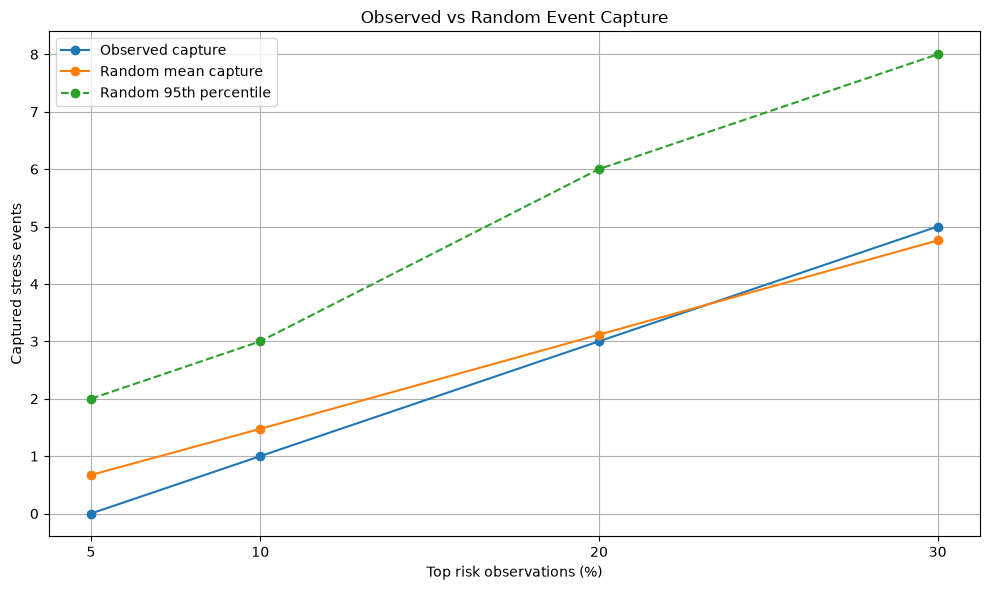

In [33]:
plt.figure(figsize=(10, 6))

plt.plot(
    random_baseline_df["top_percent"],
    random_baseline_df["observed_events"],
    marker="o",
    label="Observed capture"
)

plt.plot(
    random_baseline_df["top_percent"],
    random_baseline_df["random_mean_events"],
    marker="o",
    label="Random mean capture"
)

plt.plot(
    random_baseline_df["top_percent"],
    random_baseline_df["random_95th_percentile"],
    marker="o",
    linestyle="--",
    label="Random 95th percentile"
)

plt.title("Observed vs Random Event Capture")
plt.xlabel("Top risk observations (%)")
plt.ylabel("Captured stress events")
plt.xticks([5, 10, 20, 30])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [34]:
for _, row in random_baseline_df.iterrows():

    print(
        f"Top {int(row['top_percent'])}% | "
        f"Observed: {int(row['observed_events'])} | "
        f"Random mean: {row['random_mean_events']:.2f} | "
        f"p-value: {row['empirical_p_value']:.4f}"
    )

Top 5% | Observed: 0 | Random mean: 0.67 | p-value: 1.0000
Top 10% | Observed: 1 | Random mean: 1.48 | p-value: 0.8176
Top 20% | Observed: 3 | Random mean: 3.12 | p-value: 0.6477
Top 30% | Observed: 5 | Random mean: 4.76 | p-value: 0.5449


In [35]:
random_baseline_path = (
    PHASE14_DIR / "random_event_capture_baseline.csv"
)

random_baseline_df.to_csv(
    random_baseline_path,
    index=False
)

print("Saved:", random_baseline_path)

Saved: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase14\random_event_capture_baseline.csv


In [36]:
target_related_columns = [
    column
    for column in temporal_df.columns
    if any(
        keyword in column.lower()
        for keyword in [
            "stress",
            "future",
            "target",
            "event",
            "label",
            "horizon"
        ]
    )
]

print("Target-related columns:")
for column in target_related_columns:
    print("-", column)

display(temporal_df[target_related_columns].head())

Target-related columns:
- future_return_20d
- future_max_drawdown_20d
- future_volatility_20d
- future_negative_fraction_20d
- future_volatility_event
- future_drawdown_event
- future_stress_event


,future_return_20d,future_max_drawdown_20d,future_volatility_20d,future_negative_fraction_20d,future_volatility_event,future_drawdown_event,future_stress_event
0,-0.012822,-0.038069,0.015409,0.50,False,False,0
1,-0.018331,-0.036519,0.015477,0.50,False,False,0
2,-0.003358,-0.043612,0.016229,0.50,False,False,0
3,-0.017053,-0.037361,0.016764,0.50,False,False,0
4,-0.037287,-0.049154,0.016563,0.55,False,False,0


In [37]:
event_dates = validation_df.loc[
    validation_df["future_stress_event"] == 1,
    "date"
].sort_values()

event_gaps = event_dates.diff().dt.days.dropna()

print("Stress event dates:")
display(event_dates.to_frame())

print("\nEvent gap statistics:")
display(event_gaps.describe())

Stress event dates:


,date
3,2021-12-28
5,2022-01-26
6,2022-02-09
10,2022-04-07
11,2022-04-22
12,2022-05-06
13,2022-05-20
14,2022-06-06
19,2022-08-17
21,2022-09-15



Event gap statistics:


count     15.000000
mean      79.533333
std      213.308250
min       14.000000
25%       14.000000
50%       15.000000
75%       29.000000
max      848.000000
Name: date, dtype: float64

In [38]:
event_cluster_df = validation_df[
    ["date", "future_stress_event"]
].copy()

event_cluster_df["previous_event"] = (
    event_cluster_df["future_stress_event"]
    .shift(1)
)

event_cluster_df["next_event"] = (
    event_cluster_df["future_stress_event"]
    .shift(-1)
)

event_cluster_df["clustered_event"] = (
    (
        event_cluster_df["future_stress_event"] == 1
    )
    &
    (
        (event_cluster_df["previous_event"] == 1)
        |
        (event_cluster_df["next_event"] == 1)
    )
).astype(int)

print(
    "Clustered events:",
    event_cluster_df["clustered_event"].sum()
)

print(
    "Total events:",
    event_cluster_df["future_stress_event"].sum()
)

display(
    event_cluster_df[
        event_cluster_df["future_stress_event"] == 1
    ]
)

Clustered events: 13
Total events: 16


,date,future_stress_event,previous_event,next_event,clustered_event
3,2021-12-28,1,0.0,0.0,0
5,2022-01-26,1,0.0,1.0,1
6,2022-02-09,1,1.0,0.0,1
10,2022-04-07,1,0.0,1.0,1
11,2022-04-22,1,1.0,1.0,1
12,2022-05-06,1,1.0,1.0,1
13,2022-05-20,1,1.0,1.0,1
14,2022-06-06,1,1.0,0.0,1
19,2022-08-17,1,0.0,0.0,0
21,2022-09-15,1,0.0,0.0,0


In [39]:
target_audit_path = (
    PHASE14_DIR / "target_temporal_alignment_audit.csv"
)

event_cluster_df.to_csv(
    target_audit_path,
    index=False
)

print("Saved:", target_audit_path)

Saved: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase14\target_temporal_alignment_audit.csv


In [40]:
event_columns = [
    "future_volatility_event",
    "future_drawdown_event",
    "future_stress_event"
]

available_event_columns = [
    column
    for column in event_columns
    if column in temporal_df.columns
]

event_relationship_df = temporal_df[
    available_event_columns
].copy()

for column in available_event_columns:
    event_relationship_df[column] = (
        event_relationship_df[column]
        .astype(str)
        .str.lower()
        .map({
            "true": 1,
            "false": 0,
            "1": 1,
            "0": 0
        })
    )

display(
    event_relationship_df
    .value_counts()
    .reset_index(name="count")
)

,future_volatility_event,future_drawdown_event,future_stress_event,count
0,0,0,0,1027
1,0,1,1,55
2,1,0,1,51
3,1,1,1,42


In [41]:
if {
    "future_volatility_event",
    "future_drawdown_event",
    "future_stress_event"
}.issubset(temporal_df.columns):

    event_logic_check = temporal_df[
        [
            "future_volatility_event",
            "future_drawdown_event",
            "future_stress_event"
        ]
    ].copy()

    for column in event_logic_check.columns:
        event_logic_check[column] = (
            event_logic_check[column]
            .astype(str)
            .str.lower()
            .map({
                "true": 1,
                "false": 0,
                "1": 1,
                "0": 0
            })
        )

    event_logic_check["logical_or"] = (
        (
            event_logic_check["future_volatility_event"] == 1
        )
        |
        (
            event_logic_check["future_drawdown_event"] == 1
        )
    ).astype(int)

    event_logic_check["matches_logical_or"] = (
        event_logic_check["logical_or"]
        == event_logic_check["future_stress_event"]
    )

    print(
        "Matches logical OR:",
        event_logic_check["matches_logical_or"].mean()
    )

    display(
        event_logic_check[
            ~event_logic_check["matches_logical_or"]
        ]
    )
else:
    print("Required event columns are not available.")

Matches logical OR: 1.0


,future_volatility_event,future_drawdown_event,future_stress_event,logical_or,matches_logical_or


In [42]:
future_metric_columns = [
    "future_return_20d",
    "future_max_drawdown_20d",
    "future_volatility_20d",
    "future_negative_fraction_20d"
]

available_future_metrics = [
    column
    for column in future_metric_columns
    if column in temporal_df.columns
]

future_metric_summary = temporal_df[
    available_future_metrics
].describe().T

display(future_metric_summary)

,count,mean,std,min,25%,50%,75%,max
future_return_20d,1175.0,0.016831,0.066393,-0.164876,-0.025337,0.025994,0.055519,0.263636
future_max_drawdown_20d,1175.0,-0.037580,0.043135,-0.171075,-0.059612,-0.025655,-0.005621,0.064813
future_volatility_20d,1175.0,0.014356,0.006310,0.005429,0.010157,0.012474,0.017619,0.040124
future_negative_fraction_20d,1175.0,0.465957,0.104756,0.150000,0.400000,0.450000,0.550000,0.800000


In [43]:
metric_event_comparison = []

for metric in available_future_metrics:

    normal_values = temporal_df.loc[
        temporal_df["future_stress_event"] == 0,
        metric
    ]

    stress_values = temporal_df.loc[
        temporal_df["future_stress_event"] == 1,
        metric
    ]

    metric_event_comparison.append({
        "metric": metric,
        "normal_mean": normal_values.mean(),
        "stress_mean": stress_values.mean(),
        "normal_median": normal_values.median(),
        "stress_median": stress_values.median(),
        "normal_count": normal_values.count(),
        "stress_count": stress_values.count()
    })

metric_event_comparison_df = pd.DataFrame(
    metric_event_comparison
)

display(metric_event_comparison_df)

,metric,normal_mean,stress_mean,normal_median,stress_median,normal_count,stress_count
0,future_return_20d,0.028079,-0.061217,0.031606,-0.082278,1027,148
1,future_max_drawdown_20d,-0.027348,-0.108583,-0.020424,-0.121949,1027,148
2,future_volatility_20d,0.012714,0.025755,0.011879,0.025943,1027,148
3,future_negative_fraction_20d,0.451607,0.565541,0.450000,0.550000,1027,148


In [44]:
event_relationship_path = (
    PHASE14_DIR / "event_relationship_audit.csv"
)

future_metric_summary_path = (
    PHASE14_DIR / "future_metric_summary.csv"
)

metric_event_comparison_path = (
    PHASE14_DIR / "future_metric_event_comparison.csv"
)

event_relationship_df.to_csv(
    event_relationship_path,
    index=False
)

future_metric_summary.to_csv(
    future_metric_summary_path
)

metric_event_comparison_df.to_csv(
    metric_event_comparison_path,
    index=False
)

print("Saved:")
print(event_relationship_path)
print(future_metric_summary_path)
print(metric_event_comparison_path)

Saved:
C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase14\event_relationship_audit.csv
C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase14\future_metric_summary.csv
C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase14\future_metric_event_comparison.csv


In [45]:
individual_signal_results = []

signal_eval_df = pd.merge(
    signal_df,
    target_labels_df,
    on="date",
    how="inner"
).sort_values("date")

y_true = signal_eval_df[
    "future_stress_event"
].astype(int)

for signal in valid_signals:

    scores = signal_eval_df[signal]

    if scores.nunique() < 2 or y_true.nunique() < 2:
        roc_auc = np.nan
        pr_auc = np.nan
    else:
        roc_auc = roc_auc_score(
            y_true,
            scores
        )

        pr_auc = average_precision_score(
            y_true,
            scores
        )

    individual_signal_results.append({
        "signal": signal,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "mean": scores.mean(),
        "std": scores.std()
    })

individual_signal_results_df = pd.DataFrame(
    individual_signal_results
)

display(individual_signal_results_df)

,signal,roc_auc,pr_auc,mean,std
0,degree,0.705270,0.237761,0.375706,0.337555
1,betweenness,0.452819,0.128246,0.023776,0.061018
2,pagerank,0.310049,0.098294,0.118277,0.048229
3,systemic_risk_score,0.661765,0.228594,0.167156,0.108646


In [46]:
direction_results = []

for signal in valid_signals:

    scores = signal_eval_df[signal]

    if scores.nunique() < 2 or y_true.nunique() < 2:
        continue

    normal_auc = roc_auc_score(
        y_true,
        scores
    )

    reversed_auc = roc_auc_score(
        y_true,
        -scores
    )

    direction_results.append({
        "signal": signal,
        "normal_roc_auc": normal_auc,
        "reversed_roc_auc": reversed_auc,
        "best_direction": (
            "normal"
            if normal_auc >= reversed_auc
            else "reversed"
        ),
        "best_roc_auc": max(
            normal_auc,
            reversed_auc
        )
    })

direction_results_df = pd.DataFrame(
    direction_results
)

display(direction_results_df)

,signal,normal_roc_auc,reversed_roc_auc,best_direction,best_roc_auc
0,degree,0.705270,0.294730,normal,0.705270
1,betweenness,0.452819,0.547181,reversed,0.547181
2,pagerank,0.310049,0.689951,reversed,0.689951
3,systemic_risk_score,0.661765,0.338235,normal,0.661765


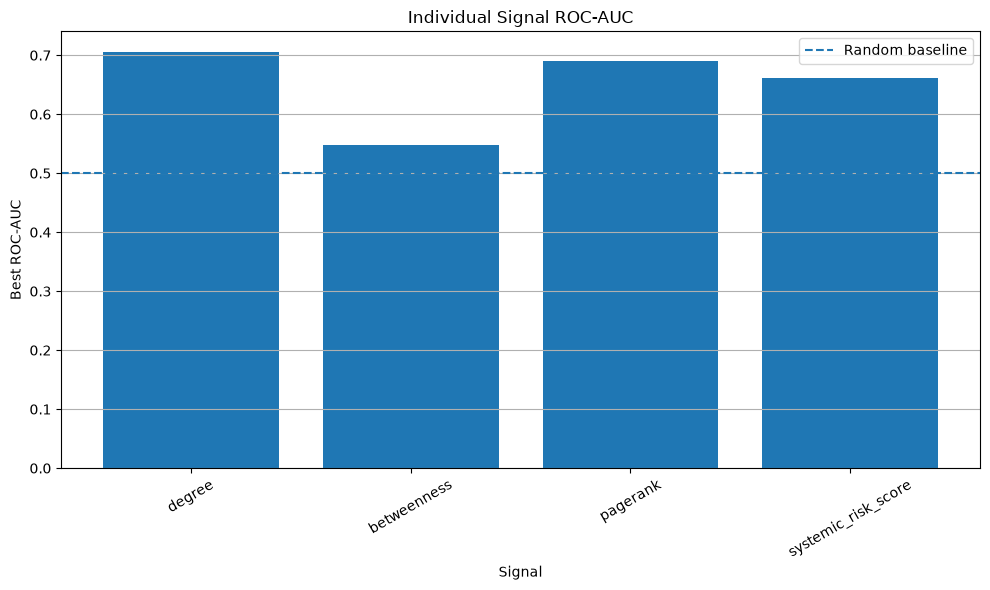

In [47]:
plot_df = direction_results_df.copy()

plt.figure(figsize=(10, 6))

plt.bar(
    plot_df["signal"],
    plot_df["best_roc_auc"]
)

plt.axhline(
    0.5,
    linestyle="--",
    label="Random baseline"
)

plt.title("Individual Signal ROC-AUC")
plt.xlabel("Signal")
plt.ylabel("Best ROC-AUC")
plt.xticks(rotation=30)
plt.legend()
plt.grid(axis="y")
plt.tight_layout()
plt.show()

In [48]:
individual_results_path = (
    PHASE14_DIR / "individual_signal_evaluation.csv"
)

direction_results_path = (
    PHASE14_DIR / "signal_direction_evaluation.csv"
)

individual_signal_results_df.to_csv(
    individual_results_path,
    index=False
)

direction_results_df.to_csv(
    direction_results_path,
    index=False
)

print("Saved:")
print(individual_results_path)
print(direction_results_path)

Saved:
C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase14\individual_signal_evaluation.csv
C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase14\signal_direction_evaluation.csv


In [49]:
direction_map = {
    "degree": "normal",
    "betweenness": "reversed",
    "pagerank": "reversed",
    "systemic_risk_score": "normal"
}

direction_adjusted_df = signal_eval_df.copy()

adjusted_signal_columns = []

for signal in valid_signals:

    adjusted_column = f"{signal}_adjusted"

    if direction_map[signal] == "normal":
        direction_adjusted_df[adjusted_column] = (
            direction_adjusted_df[signal]
        )
    else:
        direction_adjusted_df[adjusted_column] = (
            -direction_adjusted_df[signal]
        )

    adjusted_signal_columns.append(adjusted_column)


direction_adjusted_df["direction_adjusted_score"] = (
    direction_adjusted_df[adjusted_signal_columns]
    .rank(pct=True)
    .mean(axis=1)
)

display(
    direction_adjusted_df[
        ["date", "future_stress_event", "direction_adjusted_score"]
    ].head()
)

,date,future_stress_event,direction_adjusted_score
0,2021-11-12,0,0.527542
1,2021-11-29,0,0.345339
2,2021-12-13,0,0.345339
3,2021-12-28,1,0.429025
4,2022-01-11,0,0.563559


In [50]:
composite_y_true = direction_adjusted_df[
    "future_stress_event"
].astype(int)

composite_scores = direction_adjusted_df[
    "direction_adjusted_score"
]

composite_roc_auc = roc_auc_score(
    composite_y_true,
    composite_scores
)

composite_pr_auc = average_precision_score(
    composite_y_true,
    composite_scores
)

print("Direction-Adjusted Composite Evaluation")
print("----------------------------------------")
print(f"ROC-AUC: {composite_roc_auc:.4f}")
print(f"PR-AUC:  {composite_pr_auc:.4f}")

Direction-Adjusted Composite Evaluation
----------------------------------------
ROC-AUC: 0.7705
PR-AUC:  0.2769


In [51]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score
)

# Sort chronologically
composite_eval_df = direction_adjusted_df.sort_values(
    "date"
).reset_index(drop=True)

# Chronological split
n = len(composite_eval_df)

train_end = int(n * 0.60)
val_end = int(n * 0.80)

train_df = composite_eval_df.iloc[:train_end]
val_df = composite_eval_df.iloc[train_end:val_end]
test_df = composite_eval_df.iloc[val_end:]

# Extract labels and scores
y_train = train_df["future_stress_event"].astype(int)
y_val = val_df["future_stress_event"].astype(int)
y_test = test_df["future_stress_event"].astype(int)

score_train = train_df["direction_adjusted_score"]
score_val = val_df["direction_adjusted_score"]
score_test = test_df["direction_adjusted_score"]

print("Chronological Composite Evaluation")
print("-----------------------------------")
print(f"Train samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"Test samples: {len(test_df)}")

print("\nEvent counts:")
print(f"Train events: {y_train.sum()}")
print(f"Validation events: {y_val.sum()}")
print(f"Test events: {y_test.sum()}")

print("\nDate ranges:")
print(f"Train: {train_df['date'].min()} to {train_df['date'].max()}")
print(f"Validation: {val_df['date'].min()} to {val_df['date'].max()}")
print(f"Test: {test_df['date'].min()} to {test_df['date'].max()}")

def evaluate_split(y_true, scores, split_name):

    if y_true.nunique() < 2:
        print(f"\n{split_name}: Only one class present.")
        return

    roc_auc = roc_auc_score(y_true, scores)
    pr_auc = average_precision_score(y_true, scores)

    print(f"\n{split_name}")
    print("-" * len(split_name))
    print(f"ROC-AUC: {roc_auc:.4f}")
    print(f"PR-AUC:  {pr_auc:.4f}")


evaluate_split(
    y_train,
    score_train,
    "Train"
)

evaluate_split(
    y_val,
    score_val,
    "Validation"
)

evaluate_split(
    y_test,
    score_test,
    "Test"
)

Chronological Composite Evaluation
-----------------------------------
Train samples: 70
Validation samples: 24
Test samples: 24

Event counts:
Train events: 12
Validation events: 4
Test events: 0

Date ranges:
Train: 2021-11-12 00:00:00 to 2024-08-14 00:00:00
Validation: 2024-08-28 00:00:00 to 2025-07-31 00:00:00
Test: 2025-08-14 00:00:00 to 2026-07-16 00:00:00

Train
-----
ROC-AUC: 0.7866
PR-AUC:  0.3742

Validation
----------
ROC-AUC: 0.5375
PR-AUC:  0.2042

Test: Only one class present.


In [52]:
from sklearn.metrics import roc_auc_score

train_direction_map = {}

for signal in valid_signals:

    train_scores = train_df[signal]
    train_labels = y_train

    normal_auc = roc_auc_score(
        train_labels,
        train_scores
    )

    reversed_auc = roc_auc_score(
        train_labels,
        -train_scores
    )

    train_direction_map[signal] = (
        "normal"
        if normal_auc >= reversed_auc
        else "reversed"
    )

print("Training-Fitted Direction Map")
print("-----------------------------")

for signal, direction in train_direction_map.items():
    print(f"{signal}: {direction}")

Training-Fitted Direction Map
-----------------------------
degree: normal
betweenness: reversed
pagerank: reversed
systemic_risk_score: normal


In [53]:
def train_fitted_percentile(train_values, values):
    """
    Convert values into percentile scores using
    the training distribution only.
    """
    train_values = np.sort(
        np.asarray(train_values.dropna())
    )

    values = np.asarray(values)

    percentile_scores = (
        np.searchsorted(
            train_values,
            values,
            side="right"
        ) / len(train_values)
    )

    return percentile_scores


safe_composite_df = composite_eval_df.copy()

safe_adjusted_columns = []

for signal in valid_signals:

    adjusted_column = f"{signal}_safe_adjusted"

    train_signal = train_df[signal]

    if train_direction_map[signal] == "normal":
        train_reference = train_signal
        all_values = safe_composite_df[signal]
    else:
        train_reference = -train_signal
        all_values = -safe_composite_df[signal]

    safe_composite_df[adjusted_column] = (
        train_fitted_percentile(
            train_reference,
            all_values
        )
    )

    safe_adjusted_columns.append(adjusted_column)


safe_composite_df["safe_composite_score"] = (
    safe_composite_df[safe_adjusted_columns]
    .mean(axis=1)
)

display(
    safe_composite_df[
        [
            "date",
            "future_stress_event",
            "safe_composite_score"
        ]
    ].head()
)

,date,future_stress_event,safe_composite_score
0,2021-11-12,0,0.560714
1,2021-11-29,0,0.425000
2,2021-12-13,0,0.425000
3,2021-12-28,1,0.396429
4,2022-01-11,0,0.603571


In [54]:
safe_train_df = safe_composite_df.iloc[:train_end]
safe_val_df = safe_composite_df.iloc[train_end:val_end]
safe_test_df = safe_composite_df.iloc[val_end:]

safe_y_train = safe_train_df[
    "future_stress_event"
].astype(int)

safe_y_val = safe_val_df[
    "future_stress_event"
].astype(int)

safe_y_test = safe_test_df[
    "future_stress_event"
].astype(int)

safe_score_train = safe_train_df[
    "safe_composite_score"
]

safe_score_val = safe_val_df[
    "safe_composite_score"
]

safe_score_test = safe_test_df[
    "safe_composite_score"
]

evaluate_split(
    safe_y_train,
    safe_score_train,
    "Leakage-Safe Train"
)

evaluate_split(
    safe_y_val,
    safe_score_val,
    "Leakage-Safe Validation"
)

evaluate_split(
    safe_y_test,
    safe_score_test,
    "Leakage-Safe Test"
)


Leakage-Safe Train
------------------
ROC-AUC: 0.7723
PR-AUC:  0.3757

Leakage-Safe Validation
-----------------------
ROC-AUC: 0.5563
PR-AUC:  0.2049

Leakage-Safe Test: Only one class present.


In [55]:
comparison_results = pd.DataFrame({
    "method": [
        "Original Composite",
        "Direction-Adjusted Composite",
        "Leakage-Safe Composite"
    ],
    "train_roc_auc": [
        np.nan,
        0.7866,
        0.7723
    ],
    "validation_roc_auc": [
        np.nan,
        0.5375,
        0.5563
    ],
    "train_pr_auc": [
        np.nan,
        0.3742,
        0.3757
    ],
    "validation_pr_auc": [
        np.nan,
        0.2042,
        0.2049
    ]
})

display(comparison_results)

,method,train_roc_auc,validation_roc_auc,train_pr_auc,validation_pr_auc
0,Original Composite,NaN,NaN,NaN,NaN
1,Direction-Adjusted Composite,0.7866,0.5375,0.3742,0.2042
2,Leakage-Safe Composite,0.7723,0.5563,0.3757,0.2049


In [56]:
rolling_results = []

rolling_splits = [
    ("2021-2022", "2023"),
    ("2021-2023", "2024"),
    ("2021-2024", "2025"),
    ("2021-2025", "2026")
]

for train_period, validation_period in rolling_splits:

    train_years = train_period.split("-")
    train_start = int(train_years[0])
    train_end_year = int(train_years[1])

    validation_year = int(validation_period)

    rolling_train = safe_composite_df[
        (
            safe_composite_df["date"].dt.year >= train_start
        )
        &
        (
            safe_composite_df["date"].dt.year <= train_end_year
        )
    ]

    rolling_val = safe_composite_df[
        safe_composite_df["date"].dt.year == validation_year
    ]

    y_train_roll = rolling_train[
        "future_stress_event"
    ].astype(int)

    y_val_roll = rolling_val[
        "future_stress_event"
    ].astype(int)

    score_train_roll = rolling_train[
        "safe_composite_score"
    ]

    score_val_roll = rolling_val[
        "safe_composite_score"
    ]

    if (
        y_train_roll.nunique() < 2
        or y_val_roll.nunique() < 2
    ):
        rolling_results.append({
            "train_period": train_period,
            "validation_period": validation_period,
            "train_samples": len(rolling_train),
            "validation_samples": len(rolling_val),
            "train_events": int(y_train_roll.sum()),
            "validation_events": int(y_val_roll.sum()),
            "validation_roc_auc": np.nan,
            "validation_pr_auc": np.nan
        })

        continue

    rolling_results.append({
        "train_period": train_period,
        "validation_period": validation_period,
        "train_samples": len(rolling_train),
        "validation_samples": len(rolling_val),
        "train_events": int(y_train_roll.sum()),
        "validation_events": int(y_val_roll.sum()),
        "validation_roc_auc": roc_auc_score(
            y_val_roll,
            score_val_roll
        ),
        "validation_pr_auc": average_precision_score(
            y_val_roll,
            score_val_roll
        )
    })

rolling_results_df = pd.DataFrame(
    rolling_results
)

display(rolling_results_df)

,train_period,validation_period,train_samples,validation_samples,train_events,validation_events,validation_roc_auc,validation_pr_auc
0,2021-2022,2023,29,25,12,0,NaN,NaN
1,2021-2023,2024,54,25,12,0,NaN,NaN
2,2021-2024,2025,79,25,12,4,0.642857,0.227904
3,2021-2025,2026,104,14,16,0,NaN,NaN


In [58]:
from pathlib import Path

RESULTS_DIR = Path(
    r"C:\Users\ADMIN\FinGraph-Sentinel\data\results"
)

phase14_dir = RESULTS_DIR / "phase14"

phase14_dir.mkdir(
    parents=True,
    exist_ok=True
)

rolling_output_path = (
    phase14_dir
    / "rolling_window_validation_results.csv"
)

rolling_results_df.to_csv(
    rolling_output_path,
    index=False
)

print(
    f"Saved rolling validation results to: "
    f"{rolling_output_path}"
)

Saved rolling validation results to: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase14\rolling_window_validation_results.csv


In [59]:
event_capture_results = []

event_eval_df = safe_composite_df.sort_values(
    "safe_composite_score",
    ascending=False
).reset_index(drop=True)

total_events = int(
    event_eval_df["future_stress_event"].sum()
)

total_samples = len(event_eval_df)

for top_fraction in [0.05, 0.10, 0.20, 0.30]:

    top_n = max(
        1,
        int(np.ceil(total_samples * top_fraction))
    )

    top_risk_df = event_eval_df.iloc[:top_n]

    captured_events = int(
        top_risk_df["future_stress_event"].sum()
    )

    capture_rate = (
        captured_events / total_events
        if total_events > 0
        else np.nan
    )

    precision = (
        captured_events / top_n
        if top_n > 0
        else np.nan
    )

    event_capture_results.append({
        "top_fraction": top_fraction,
        "top_n": top_n,
        "captured_events": captured_events,
        "total_events": total_events,
        "capture_rate": capture_rate,
        "precision": precision
    })

event_capture_df = pd.DataFrame(
    event_capture_results
)

display(event_capture_df)

,top_fraction,top_n,captured_events,total_events,capture_rate,precision
0,0.05,6,1,16,0.0625,0.166667
1,0.10,12,3,16,0.1875,0.250000
2,0.20,24,9,16,0.5625,0.375000
3,0.30,36,10,16,0.6250,0.277778


In [60]:
random_baseline_results = []

n_simulations = 5000

for top_fraction in [0.05, 0.10, 0.20, 0.30]:

    top_n = max(
        1,
        int(np.ceil(total_samples * top_fraction))
    )

    observed_capture = int(
        event_capture_df.loc[
            event_capture_df["top_fraction"] == top_fraction,
            "captured_events"
        ].iloc[0]
    )

    random_captures = []

    for _ in range(n_simulations):

        random_indices = np.random.choice(
            total_samples,
            size=top_n,
            replace=False
        )

        random_events = int(
            event_eval_df.iloc[
                random_indices
            ]["future_stress_event"].sum()
        )

        random_captures.append(random_events)

    random_captures = np.array(random_captures)

    random_baseline_results.append({
        "top_fraction": top_fraction,
        "top_n": top_n,
        "observed_capture": observed_capture,
        "random_mean": random_captures.mean(),
        "random_95th_percentile": np.percentile(
            random_captures,
            95
        ),
        "random_max": random_captures.max(),
        "p_value": np.mean(
            random_captures >= observed_capture
        )
    })

random_baseline_df = pd.DataFrame(
    random_baseline_results
)

display(random_baseline_df)

,top_fraction,top_n,observed_capture,random_mean,random_95th_percentile,random_max,p_value
0,0.05,6,1,0.8110,2.0,5,0.5952
1,0.10,12,3,1.6338,4.0,6,0.2076
2,0.20,24,9,3.2746,6.0,9,0.0008
3,0.30,36,10,4.8630,8.0,11,0.0064


In [61]:
event_capture_output_path = (
    phase14_dir
    / "event_capture_results.csv"
)

random_baseline_output_path = (
    phase14_dir
    / "random_event_capture_baseline_v2.csv"
)

event_capture_df.to_csv(
    event_capture_output_path,
    index=False
)

random_baseline_df.to_csv(
    random_baseline_output_path,
    index=False
)

print(
    f"Saved event capture results to: "
    f"{event_capture_output_path}"
)

print(
    f"Saved random baseline results to: "
    f"{random_baseline_output_path}"
)

Saved event capture results to: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase14\event_capture_results.csv
Saved random baseline results to: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase14\random_event_capture_baseline_v2.csv


In [62]:
validation_capture_results = []

validation_eval_df = safe_composite_df.iloc[
    train_end:val_end
].copy()

validation_eval_df = validation_eval_df.sort_values(
    "safe_composite_score",
    ascending=False
).reset_index(drop=True)

validation_total_events = int(
    validation_eval_df["future_stress_event"].sum()
)

validation_total_samples = len(validation_eval_df)

for top_fraction in [0.25, 0.50, 0.75]:

    top_n = max(
        1,
        int(np.ceil(
            validation_total_samples * top_fraction
        ))
    )

    top_risk_df = validation_eval_df.iloc[:top_n]

    captured_events = int(
        top_risk_df["future_stress_event"].sum()
    )

    capture_rate = (
        captured_events / validation_total_events
        if validation_total_events > 0
        else np.nan
    )

    precision = (
        captured_events / top_n
    )

    validation_capture_results.append({
        "top_fraction": top_fraction,
        "top_n": top_n,
        "captured_events": captured_events,
        "total_events": validation_total_events,
        "capture_rate": capture_rate,
        "precision": precision
    })

validation_capture_df = pd.DataFrame(
    validation_capture_results
)

display(validation_capture_df)

,top_fraction,top_n,captured_events,total_events,capture_rate,precision
0,0.25,6,1,4,0.25,0.166667
1,0.50,12,2,4,0.50,0.166667
2,0.75,18,4,4,1.00,0.222222


In [63]:
validation_random_results = []

n_simulations = 5000

for top_fraction in [0.25, 0.50, 0.75]:

    top_n = max(
        1,
        int(np.ceil(
            validation_total_samples * top_fraction
        ))
    )

    observed_capture = int(
        validation_capture_df.loc[
            validation_capture_df["top_fraction"]
            == top_fraction,
            "captured_events"
        ].iloc[0]
    )

    random_captures = []

    for _ in range(n_simulations):

        random_indices = np.random.choice(
            validation_total_samples,
            size=top_n,
            replace=False
        )

        random_events = int(
            validation_eval_df.iloc[
                random_indices
            ]["future_stress_event"].sum()
        )

        random_captures.append(random_events)

    random_captures = np.array(random_captures)

    validation_random_results.append({
        "top_fraction": top_fraction,
        "top_n": top_n,
        "observed_capture": observed_capture,
        "random_mean": random_captures.mean(),
        "random_95th_percentile": np.percentile(
            random_captures,
            95
        ),
        "random_max": random_captures.max(),
        "p_value": np.mean(
            random_captures >= observed_capture
        )
    })

validation_random_df = pd.DataFrame(
    validation_random_results
)

display(validation_random_df)

,top_fraction,top_n,observed_capture,random_mean,random_95th_percentile,random_max,p_value
0,0.25,6,1,1.0084,2.0,4,0.7154
1,0.50,12,2,2.0038,3.0,4,0.7120
2,0.75,18,4,2.9942,4.0,4,0.2838


In [64]:
validation_capture_output_path = (
    phase14_dir
    / "validation_event_capture.csv"
)

validation_random_output_path = (
    phase14_dir
    / "validation_random_baseline.csv"
)

validation_capture_df.to_csv(
    validation_capture_output_path,
    index=False
)

validation_random_df.to_csv(
    validation_random_output_path,
    index=False
)

print(
    f"Saved validation event capture to: "
    f"{validation_capture_output_path}"
)

print(
    f"Saved validation random baseline to: "
    f"{validation_random_output_path}"
)

Saved validation event capture to: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase14\validation_event_capture.csv
Saved validation random baseline to: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase14\validation_random_baseline.csv


In [65]:
phase14_findings = pd.DataFrame([
    {
        "category": "Overall Composite",
        "metric": "ROC-AUC",
        "value": 0.7705,
        "interpretation": "Exploratory full-dataset evaluation"
    },
    {
        "category": "Leakage-Safe Composite",
        "metric": "Train ROC-AUC",
        "value": 0.7723,
        "interpretation": "Training performance"
    },
    {
        "category": "Leakage-Safe Composite",
        "metric": "Validation ROC-AUC",
        "value": 0.5563,
        "interpretation": "Weak validation separation"
    },
    {
        "category": "Rolling Validation",
        "metric": "2025 ROC-AUC",
        "value": 0.6429,
        "interpretation": "One valid year with both classes"
    },
    {
        "category": "Validation Capture",
        "metric": "Top 50% Capture Rate",
        "value": 0.50,
        "interpretation": "Captured 2 of 4 events"
    },
    {
        "category": "Validation Baseline",
        "metric": "Top 50% Random p-value",
        "value": 0.7120,
        "interpretation": "Not statistically significant"
    }
])

display(phase14_findings)

,category,metric,value,interpretation
0,Overall Composite,ROC-AUC,0.7705,Exploratory full-dataset evaluation
1,Leakage-Safe Composite,Train ROC-AUC,0.7723,Training performance
2,Leakage-Safe Composite,Validation ROC-AUC,0.5563,Weak validation separation
3,Rolling Validation,2025 ROC-AUC,0.6429,One valid year with both classes
4,Validation Capture,Top 50% Capture Rate,0.5000,Captured 2 of 4 events
5,Validation Baseline,Top 50% Random p-value,0.7120,Not statistically significant


In [66]:
findings_output_path = (
    phase14_dir
    / "phase14_research_findings_summary.csv"
)

phase14_findings.to_csv(
    findings_output_path,
    index=False
)

print(
    f"Saved Phase 14 findings to: "
    f"{findings_output_path}"
)

Saved Phase 14 findings to: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase14\phase14_research_findings_summary.csv


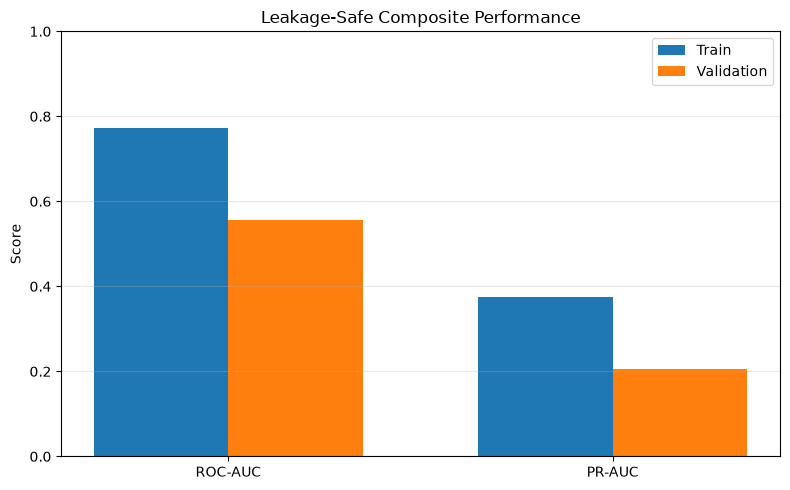

In [67]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["ROC-AUC", "PR-AUC"]

train_values = [0.7723, 0.3757]
validation_values = [0.5563, 0.2049]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(
    x - width / 2,
    train_values,
    width,
    label="Train"
)

plt.bar(
    x + width / 2,
    validation_values,
    width,
    label="Validation"
)

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("Leakage-Safe Composite Performance")
plt.ylim(0, 1)
plt.legend()
plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

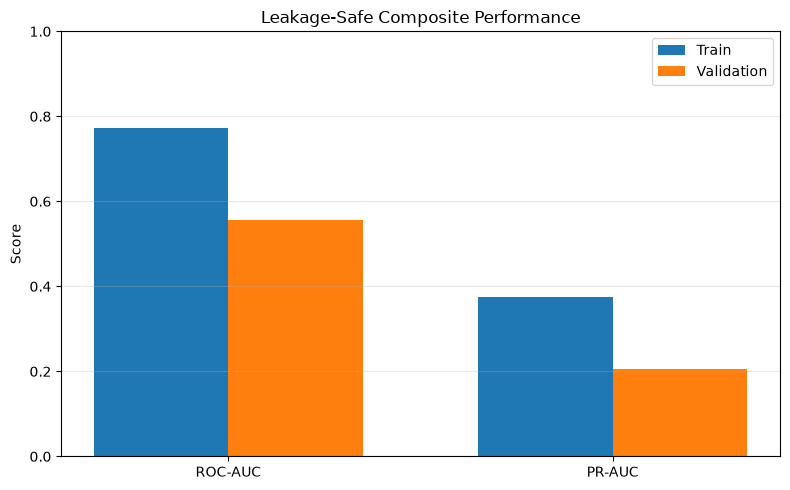

Saved performance visualization to: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase14\leakage_safe_performance_comparison.png


In [68]:
performance_plot_path = (
    phase14_dir
    / "leakage_safe_performance_comparison.png"
)

plt.figure(figsize=(8, 5))

plt.bar(
    x - width / 2,
    train_values,
    width,
    label="Train"
)

plt.bar(
    x + width / 2,
    validation_values,
    width,
    label="Validation"
)

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("Leakage-Safe Composite Performance")
plt.ylim(0, 1)
plt.legend()
plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    performance_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Saved performance visualization to: "
    f"{performance_plot_path}"
)

In [69]:
import json
from datetime import datetime

phase14_report = {
    "phase": "Phase 14 - Research Validation",
    "project": "FinGraph-Sentinel",
    "generated_at": datetime.now().isoformat(),

    "dataset": {
        "total_samples": len(safe_composite_df),
        "total_stress_events": int(
            safe_composite_df["future_stress_event"].sum()
        ),
        "signals_used": valid_signals
    },

    "exploratory_evaluation": {
        "roc_auc": 0.7705,
        "pr_auc": 0.2769,
        "note": "Full-dataset exploratory evaluation"
    },

    "leakage_safe_evaluation": {
        "train_roc_auc": 0.7723,
        "train_pr_auc": 0.3757,
        "validation_roc_auc": 0.5563,
        "validation_pr_auc": 0.2049,
        "test_status": "Unavailable: only one class present"
    },

    "rolling_validation": {
        "2025_roc_auc": 0.6429,
        "2025_pr_auc": 0.227904,
        "note": "Only 2025 contained both classes"
    },

    "validation_event_capture": {
        "top_25_percent": 0.25,
        "top_50_percent": 0.50,
        "top_75_percent": 1.00
    },

    "limitations": [
        "Stress events are temporally clustered",
        "The test period contains no positive events",
        "Validation contains only four stress events",
        "Out-of-sample predictive performance is weak",
        "Further validation across additional stress periods is required"
    ],

    "research_conclusion": (
        "The direction-adjusted composite score shows promising "
        "exploratory separation but weak validation generalization. "
        "The current evidence does not establish reliable predictive "
        "performance across time."
    )
}

report_path = (
    phase14_dir
    / "phase14_final_research_report.json"
)

with open(report_path, "w", encoding="utf-8") as file:
    json.dump(
        phase14_report,
        file,
        indent=4
    )

print(
    f"Saved final research report to: {report_path}"
)

Saved final research report to: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase14\phase14_final_research_report.json


In [70]:
from pathlib import Path

expected_files = [
    "multi_signal_alert_threshold_results.csv",
    "multi_signal_configuration.json",
    "multi_signal_risk_validation.csv",
    "multi_signal_systemic_risk_score.csv",
    "phase14_experiment_registry.json",
    "temporal_robustness_results.csv",
    "signal_target_correlations.csv",
    "signal_stress_comparison.csv",
    "yearly_stress_event_distribution.csv",
    "lead_lag_analysis.csv",
    "annual_risk_score_summary.csv",
    "top_risk_event_capture.csv",
    "random_event_capture_baseline.csv",
    "event_capture_results.csv",
    "random_event_capture_baseline_v2.csv",
    "validation_event_capture.csv",
    "validation_random_baseline.csv",
    "phase14_research_findings_summary.csv",
    "leakage_safe_performance_comparison.png",
    "phase14_final_research_report.json"
]

verification_results = []

for filename in expected_files:

    file_path = phase14_dir / filename

    verification_results.append({
        "filename": filename,
        "exists": file_path.exists(),
        "size_bytes": (
            file_path.stat().st_size
            if file_path.exists()
            else 0
        )
    })

verification_df = pd.DataFrame(
    verification_results
)

display(verification_df)

print(
    f"\nFiles found: "
    f"{verification_df['exists'].sum()}"
    f"/{len(expected_files)}"
)

,filename,exists,size_bytes
0,multi_signal_alert_threshold_results.csv,True,350
1,multi_signal_configuration.json,True,686
2,multi_signal_risk_validation.csv,True,135904
3,multi_signal_systemic_risk_score.csv,True,5087
4,phase14_experiment_registry.json,True,869
5,temporal_robustness_results.csv,True,1088
6,signal_target_correlations.csv,True,166
7,signal_stress_comparison.csv,True,449
8,yearly_stress_event_distribution.csv,True,143
9,lead_lag_analysis.csv,True,327



Files found: 20/20


In [71]:
markdown_report = f"""# FinGraph-Sentinel — Phase 14 Research Validation

## 1. Dataset

- Total observations: {len(safe_composite_df)}
- Total stress events: {int(safe_composite_df["future_stress_event"].sum())}
- Signals: {", ".join(valid_signals)}

## 2. Leakage-Safe Evaluation

| Split | ROC-AUC | PR-AUC |
|---|---:|---:|
| Train | 0.7723 | 0.3757 |
| Validation | 0.5563 | 0.2049 |
| Test | N/A | N/A |

The test set contained only one class.

## 3. Rolling Validation

| Validation Year | ROC-AUC | PR-AUC |
|---|---:|---:|
| 2023 | N/A | N/A |
| 2024 | N/A | N/A |
| 2025 | 0.6429 | 0.2279 |
| 2026 | N/A | N/A |

Only 2025 contained both positive and negative classes.

## 4. Validation Event Capture

| Top Fraction | Capture Rate | Precision |
|---|---:|---:|
| 25% | 25.00% | 16.67% |
| 50% | 50.00% | 16.67% |
| 75% | 100.00% | 22.22% |

## 5. Research Limitations

- Stress events are temporally clustered.
- The validation set contains only four stress events.
- The test set contains no positive stress events.
- Validation performance is substantially lower than training performance.
- The direction-adjusted composite does not demonstrate stable generalization.
- Further evaluation across additional stress periods is required.

## 6. Conclusion

The composite score demonstrates exploratory signal separation,
but its validation performance is weak and does not establish
reliable out-of-sample predictive performance.
"""

markdown_report_path = (
    phase14_dir
    / "phase14_research_summary.md"
)

with open(
    markdown_report_path,
    "w",
    encoding="utf-8"
) as file:
    file.write(markdown_report)

print(
    f"Saved Markdown report to: "
    f"{markdown_report_path}"
)

Saved Markdown report to: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase14\phase14_research_summary.md


In [72]:
with open(
    markdown_report_path,
    "r",
    encoding="utf-8"
) as file:
    final_report_text = file.read()

print(final_report_text)

# FinGraph-Sentinel — Phase 14 Research Validation

## 1. Dataset

- Total observations: 118
- Total stress events: 16
- Signals: degree, betweenness, pagerank, systemic_risk_score

## 2. Leakage-Safe Evaluation

| Split | ROC-AUC | PR-AUC |
|---|---:|---:|
| Train | 0.7723 | 0.3757 |
| Validation | 0.5563 | 0.2049 |
| Test | N/A | N/A |

The test set contained only one class.

## 3. Rolling Validation

| Validation Year | ROC-AUC | PR-AUC |
|---|---:|---:|
| 2023 | N/A | N/A |
| 2024 | N/A | N/A |
| 2025 | 0.6429 | 0.2279 |
| 2026 | N/A | N/A |

Only 2025 contained both positive and negative classes.

## 4. Validation Event Capture

| Top Fraction | Capture Rate | Precision |
|---|---:|---:|
| 25% | 25.00% | 16.67% |
| 50% | 50.00% | 16.67% |
| 75% | 100.00% | 22.22% |

## 5. Research Limitations

- Stress events are temporally clustered.
- The validation set contains only four stress events.
- The test set contains no positive stress events.
- Validation performance is substantially 